In [1]:
import torch
import torch.nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

device

device(type='cuda')

In [3]:
BATCH_SIZE = 128

transform = transforms.Compose(
    [
        transforms.ToTensor(),
    ]
)

train_dataset = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)

In [4]:
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

## VAE Class


In [5]:
latent_dim = 128


class VAE(torch.nn.Module):
    def __init__(self, input_dim=28 * 28, hidden_dim=256, latent_dim=latent_dim):
        output_dim = input_dim

        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        # Encoder
        self.encoder = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim, hidden_dim // 2),
            torch.nn.ReLU(),
        )

        self.fc_mu = torch.nn.Linear(hidden_dim // 2, latent_dim)
        self.fc_logvar = torch.nn.Linear(hidden_dim // 2, latent_dim)

        # Decoder
        self.decoder = torch.nn.Sequential(
            torch.nn.Linear(latent_dim, hidden_dim // 2),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim // 2, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim, output_dim),
            torch.nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 28 * 28))
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar

## Coding the Loss


In [6]:
def vae_loss(recon_x, x, mu, logvar):
    MSE = torch.nn.functional.mse_loss(recon_x, x, reduction="sum")

    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return MSE + KLD

In [7]:
model = VAE().to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [8]:
epochs = 15

model.train()

for epoch in range(epochs):
    train_loss = 0

    for x, _ in train_loader:
        x = x.view(-1, 28 * 28).to(device)

        optimizer.zero_grad()
        x_recon, mu, logvar = model(x)
        loss = vae_loss(x_recon, x, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

    avg_loss = train_loss / len(train_loader.dataset)

    print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.6f}")

Epoch 1/15, Loss: 52.602310
Epoch 2/15, Loss: 44.413315
Epoch 3/15, Loss: 39.736213
Epoch 4/15, Loss: 36.099412
Epoch 5/15, Loss: 34.606224
Epoch 6/15, Loss: 33.298064
Epoch 7/15, Loss: 32.360209
Epoch 8/15, Loss: 31.735344
Epoch 9/15, Loss: 31.146205
Epoch 10/15, Loss: 30.790063
Epoch 11/15, Loss: 30.460311
Epoch 12/15, Loss: 30.219703
Epoch 13/15, Loss: 30.016645
Epoch 14/15, Loss: 29.818402
Epoch 15/15, Loss: 29.641564


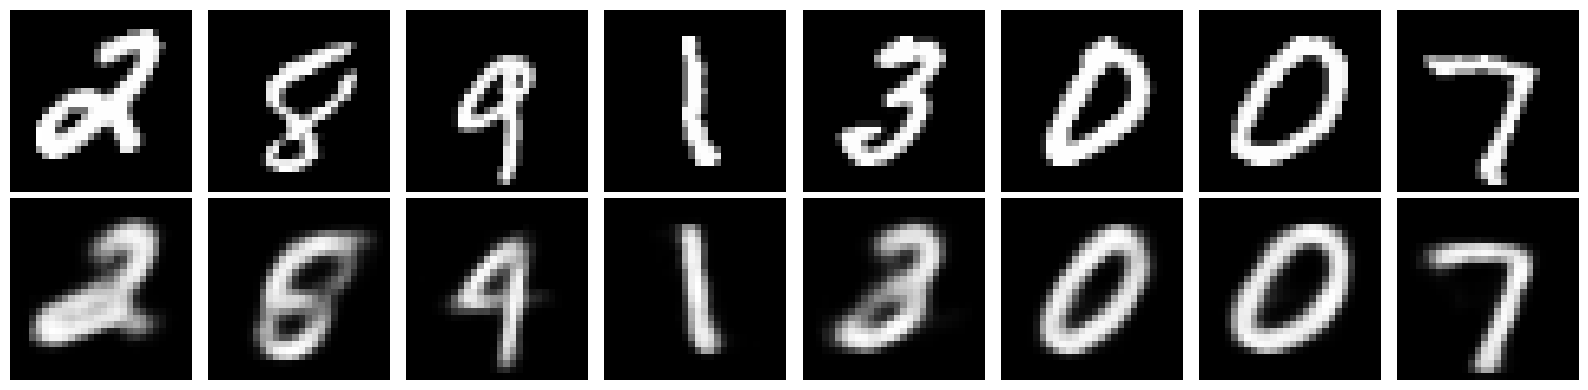

In [9]:
# %% Plot 8 original vs reconstructed images

model.eval()

# Get one batch of test-like images from the training set
images, _ = next(iter(train_loader))
images = images[:8].to(device)

with torch.no_grad():
    recon_images, _, _ = model(images)

# Move to CPU and reshape
images = images.cpu()
recon_images = recon_images.view(-1, 1, 28, 28).cpu()

# Plot
fig, axes = plt.subplots(2, 8, figsize=(16, 4))

for i in range(8):
    # Original
    axes[0, i].imshow(images[i].squeeze(), cmap="gray")
    axes[0, i].axis("off")

    # Reconstruction
    axes[1, i].imshow(recon_images[i].squeeze(), cmap="gray")
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=12)
axes[1, 0].set_ylabel("Reconstructed", fontsize=12)

plt.tight_layout()
plt.show()

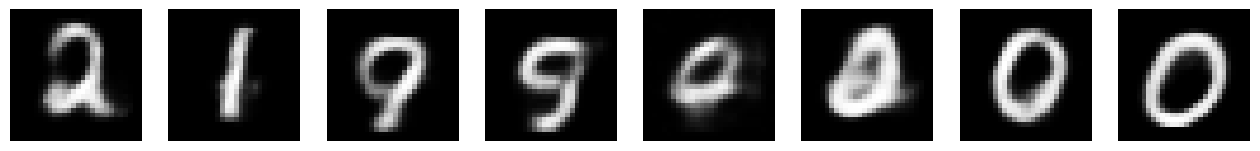

In [13]:
with torch.no_grad():
    # Sample from the latent space
    z = torch.randn(8, latent_dim).to(device)
    samples = model.decode(z).view(-1, 1, 28, 28).cpu()

# Plot the generated samples
fig, axes = plt.subplots(1, 8, figsize=(16, 2))

for i in range(8):
    axes[i].imshow(samples[i].squeeze(), cmap="gray")
    axes[i].axis("off")

plt.show()

Latent representation shape: torch.Size([10000, 128])
PCA output shape: (10000, 2)
Explained variance ratio: [0.17041367 0.15043697]
Total explained variance: 0.32085064


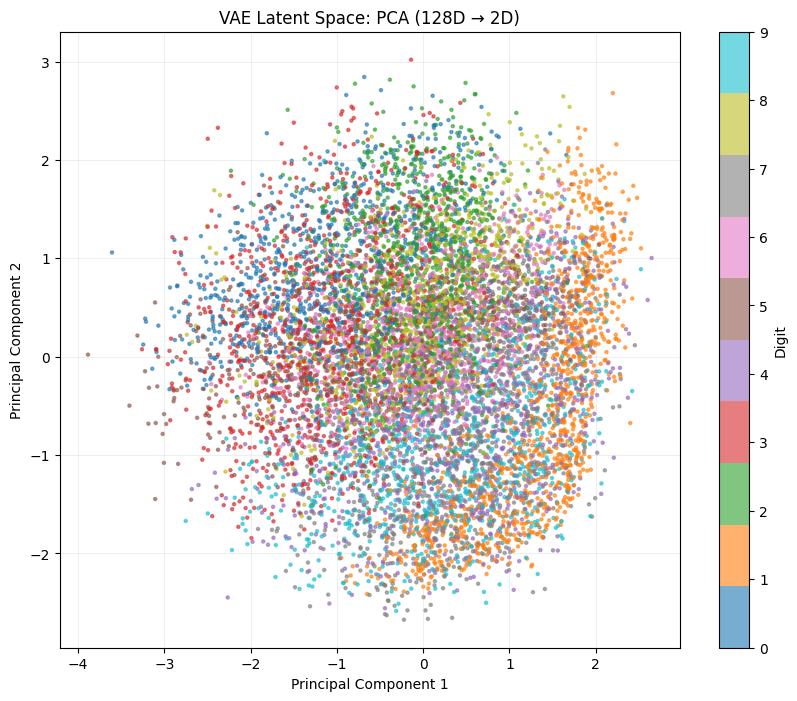

In [15]:
# %% Plot 2D latent space using PCA

from sklearn.decomposition import PCA

model.eval()

latent_vectors = []
labels = []

with torch.no_grad():
    for images, y in train_loader:
        images = images.to(device)

        # Get all 128 latent dimensions
        mu, logvar = model.encode(images.view(-1, 28 * 28))

        latent_vectors.append(mu.cpu())
        labels.append(y)

        # Stop after collecting enough samples
        if sum(x.size(0) for x in latent_vectors) >= 10000:
            break

# Combine all batches
latent_vectors = torch.cat(latent_vectors)[:10000]
labels = torch.cat(labels)[:10000]

print("Latent representation shape:", latent_vectors.shape)
# Expected: torch.Size([10000, 128])

# Convert to NumPy
latent_vectors_np = latent_vectors.numpy()
labels_np = labels.numpy()

# PCA: 128 dimensions -> 2 dimensions
pca = PCA(n_components=2)

z_2d = pca.fit_transform(latent_vectors_np)

print("PCA output shape:", z_2d.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

# Plot
plt.figure(figsize=(10, 8))

scatter = plt.scatter(z_2d[:, 0], z_2d[:, 1], c=labels_np, cmap="tab10", s=5, alpha=0.6)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("VAE Latent Space: PCA (128D → 2D)")

plt.colorbar(scatter, ticks=range(10), label="Digit")

plt.grid(alpha=0.2)
plt.show()